# Distractor sex conditions pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


### Get model results from full SWC experiment - same stimuli as in human experiment 

In [2]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']

cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [3]:

# model_names = ["word_task_mono_arch_v07", "word_task_diotic_arch_v07_gend_bal", "word_task_standard_v07", "word_task_half_co_loc_v07",
#              "word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
             

# model_names = ["word_task_standard_v07", "word_task_standard_v07_gend_bal", "word_task_half_co_loc_v07",
#              "word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
             

# model_names = ["word_task_standard_v07", "word_task_half_co_loc_v07", "word_task_20p_loc_v07_wider_SNR", 'word_task_20p_loc_v07_wider_SNR_residual_attn', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
# model_names = ["word_task_standard_v08", "word_task_25p_loc_v07_LN_last_valid_time_no_affine"]
model_names = ["word_task_half_co_loc_v08_gender_bal_4M_sanity",
            ]
             
model_name_dict = {"attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor": "Mono WordSpeakerNoise",
                   "word_task_standard_v07_gend_bal": "Binaural CV gend bal no pitch aug.",
                   "word_task_mono_arch_v06": "Mono CommonVoice",
                   "word_task_half_co_loc_v07": "50% co-located v07",
                   "word_task_half_co_loc_v08":  "Standard v08",                                        # half_co_loc_v08 is actually just standard spatialization  
                   "word_task_standard_v07": "Binaural CV no pitch augments",
                   "word_task_standard_v08": "Binaural v08",
                   "word_task_half_co_loc_v08_70p_same": "Half co-loc 70p same-sex v08",
                   "word_task_mono_arch_v07": "Mono CV no pitch augments",
                   "word_task_diotic_arch_v07": "Diotic CV no pitch augments",
                   "word_task_diotic_arch_v07_gend_bal": "Diotic CV gend bal no pitch aug.",
                   "word_task_20p_loc_v07_wider_SNR": "25% co-located wider SNR", # are really 25% co-located
                   "word_task_20p_loc_v07_wider_SNR_residual_attn": "25% co-located wider SNR residual attn", # are really 25% co-located
                   "word_task_25p_loc_v07_LN_last_valid_time_no_affine": "25% co-located LN last valid time no affine",
                   "word_task_quarter_co_loc_v08": "v08 25% co-located",
                   "word_task_standard_v08_70p_same_dist": "70% same-sex distractor" ,
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
                   "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
                   "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
                   "word_task_deep_fc_1024_v08": "Deeper Architecture",
                   "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
                   "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt"
                  }


manifests = pd.read_pickle("/om2/user/imgriff/datasets/spatial_audio_pipeline/assets/human_attn_experiment_v00/screened_eval_trial_manifest_new_fnames_w_transcripts_and_f0.pdpkl")

manifests['test_index'] = manifests.index

all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "stationary": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "clean": "SILENCE"}

str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 

for model_name in model_names:
    if "v0" in model_name:
        output_paths = list(Path(f'swc_mono_eval_full_stim/{model_name}').glob('*.csv'))
        print(len(output_paths))

    elif model_name == "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor":
        output_paths = list(Path(f'../Auditory-Attention/swc_mono_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))
    results_dfs = []


    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')   
        # use re to split path.stem after model name and before <int>dB 
        if 'one_distractor' in path.stem:
            df['background_condition'] = '1-talker'
        elif 'four_distractor' in path.stem:
            df['background_condition'] = '4-talker'
        elif 'natural' in path.stem:
            df['background_condition'] = 'natural scene'
        else:
            df['background_condition'] = [k for k in test_condition_dict.keys() if k in path.stem][0]
    
        if 'clean' in path.stem:
            df['background_condition'] = 'clean'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        df['test_index'] = df.index
        df = pd.merge(df,
            manifests[["test_index", "word", "word_int", 'gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                        left_on=["test_index", "true_word_int"], right_on=["test_index", "word_int"])
        if df['snr'].iloc[0] == -12:
            continue
        results_dfs.append(df)


    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name]
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_str else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    distractor_words = model_results.distractor_word.values
    distractor_transcripts = model_results.distractor_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                                if not isinstance(distractor_transcript, float) else np.nan
                                for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                                ])
    
    model_results['accuracy'] = adjusted_acc
    model_results['confusions'] = adjusted_confs
    

    model_results = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
    model_results.loc[:, 'sex_cond'] = model_results.apply(lambda row: 'same' if row['gender'] == row['distractor_gender'] else 'different', axis=1)
    model_results.loc[model_results.background_condition == 'clean', 'sex_cond'] = 'clean'
    model_results.loc[:, "abs_f0_diff"] = np.abs(model_results.target_f0 - model_results.distractor_f0)
    model_results.loc[:, "percent_f0_diff"] = model_results.distractor_f0 / model_results.target_f0 
    all_model_results.append(model_results)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)


43


### Load human data

In [4]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_distractor_sex_v02/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)


101

In [5]:
# human_fnames

In [6]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
print(results_df.id_subject.nunique())
## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
print(results_df.id_subject.nunique())


## Add snr and condition names as columns - unpack from file code in file names 

import re
### Get condition map
with open('/om/user/imgriff/datasets/human_distractor_sex_no_cue_level_match_2024/human_distractor_sex_cond_map.pkl', 'rb') as f:
    stim_cond_map = pickle.load(f)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    target_cond, dist_cond, snr = None,  None, None
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            target_cond, dist_cond, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            snr = 'inf'
            target_cond = 'catch_trial'
            dist_cond = 'catch_trial'
    return target_cond, dist_cond, snr

# add as columns 
results_df['target_sex'], results_df['sex_cond'], results_df['snr'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))
results_df.loc[results_df['sex_cond'] == 'SILENCE', 'sex_cond'] = 'clean'
# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]


# # screen based on completion 
total_trials = 342 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').sex_cond.count() >= total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# # Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Expecting ':' delimiter: line 1 column 263704 (char 263703)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex_v02/data/subj_650ee274aa4447ac435b7830.json
Unterminated string starting at: line 1 column 383054 (char 383053)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex_v02/data/subj_5be8dab5d153f500019ab320.json
Unterminated string starting at: line 1 column 382981 (char 382980)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex_v02/data/subj_665fd10bde2c89d3d93cad35.json
Expecting ':' delimiter: line 1 column 311717 (char 311716)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex_v02/data/subj_667996733e36c7f5d3ab9cab.json
Expecting ':' delimiter: line 1 column 383232 (char 383231)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex_v02/data/subj_663032f971fff2cdf666195b.json
95
69


In [34]:
trial_results[(trial_results.sex_cond == 'catch_trial') & (trial_results.correct_response != 'thing')]

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,catch_trial,correct_response,trial_num,correct,n_correct,n_incorrect,target_sex,sex_cond,snr,accuracy
59,NaN,NaN,NaN,NaN,NaN,dictionary-text,59,516883,0.0-12.0-1.0-1.14,cocktail_party_distractor_sex_v02/data/subj_65...,...,1.0,other,14.0,1.0,7.0,8.0,catch_trial,catch_trial,inf,1
284,NaN,NaN,NaN,NaN,NaN,dictionary-text,284,1376463,0.0-12.0-1.0-1.89,cocktail_party_distractor_sex_v02/data/subj_65...,...,1.0,there,89.0,1.0,56.0,34.0,catch_trial,catch_trial,inf,1
335,NaN,NaN,NaN,NaN,NaN,dictionary-text,335,1541465,0.0-12.0-1.0-1.106,cocktail_party_distractor_sex_v02/data/subj_65...,...,1.0,could,106.0,1.0,68.0,39.0,catch_trial,catch_trial,inf,1
353,NaN,NaN,NaN,NaN,NaN,dictionary-text,353,1597045,0.0-12.0-1.0-1.112,cocktail_party_distractor_sex_v02/data/subj_65...,...,1.0,great,112.0,1.0,72.0,41.0,catch_trial,catch_trial,inf,1
458,NaN,NaN,NaN,NaN,NaN,dictionary-text,458,1932658,0.0-12.0-1.0-1.147,cocktail_party_distractor_sex_v02/data/subj_65...,...,1.0,years,147.0,1.0,98.0,50.0,catch_trial,catch_trial,inf,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,NaN,NaN,NaN,NaN,NaN,dictionary-text,683,8239063,0.0-12.0-1.0-1.222,cocktail_party_distractor_sex_v02/data/subj_66...,...,1.0,because,222.0,1.0,52.0,171.0,catch_trial,catch_trial,inf,0
725,NaN,NaN,NaN,NaN,NaN,dictionary-text,725,8656407,0.0-12.0-1.0-1.236,cocktail_party_distractor_sex_v02/data/subj_66...,...,1.0,called,236.0,1.0,54.0,183.0,catch_trial,catch_trial,inf,1
872,NaN,NaN,NaN,NaN,NaN,dictionary-text,872,9743762,0.0-12.0-1.0-1.285,cocktail_party_distractor_sex_v02/data/subj_66...,...,1.0,going,285.0,1.0,59.0,227.0,catch_trial,catch_trial,inf,0
893,NaN,NaN,NaN,NaN,NaN,dictionary-text,893,9871876,0.0-12.0-1.0-1.292,cocktail_party_distractor_sex_v02/data/subj_66...,...,1.0,thought,292.0,0.0,59.0,234.0,catch_trial,catch_trial,inf,0


In [40]:

trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[(trial_results.sex_cond == 'catch_trial') & (trial_results.correct_response != 'thing')].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >=9/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.sex_cond.isnull()) & (~good_results.response.isna())]
N = analysis_df.id_subject.nunique()
# analysis_df.groupby('id_subject').sex_cond.count()

N total participants  52
N good participants  47


#### Add meta to participant df 


In [41]:
analysis_df['trial_int'] = analysis_df.stimulus.apply(lambda x: int(x.split('/')[-1].split('.')[0]))
analysis_df['condition_dir'] = analysis_df.stimulus.apply(lambda x: x.split('/')[1])

In [42]:
! ls /om/user/imgriff/datasets/human_distractor_sex_2024/

full_expmt_stim_manifest.pdpkl	   human_distractor_sex_word_key.js
full_stim_manifest_w_fnames.pdpkl  human_distractor_sex_word_key.pkl
human_distractor_sex_cond_map.pkl  sounds


In [43]:
### Look at 1 talker sex conditions

human_manifests = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_sex_no_cue_level_match_2024/full_expmt_stim_manifest_w_transcripts_and_f0.pdpkl')

## Add f0 to human manifest
# human_manifests = pd.merge(human_manifests, manifests[['client_id', 'word_int', 'distractor_word', 'gender_cond_td',
#                                      'target_f0', 'distractor_f0']],
#          left_on=['client_id', 'word_int','distractor_word', 'gender_cond_td'],
#          right_on=['client_id', 'word_int', 'distractor_word', 'gender_cond_td'])

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from human_manifests to trial_results where trial_results.stimulus == human_manifests.base_str
human_manifests.rename(columns={"distractor_1_transcripts": "distractor_transcripts"}, inplace=True)
analysis_df = pd.merge(analysis_df,
                        human_manifests[['condition_dir', 'word', 'gender', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts', 'target_f0', 'distractor_f0']],
                                    left_on=['condition_dir', 'correct_response'], right_on=['condition_dir', 'word'], how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')

# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.correct_response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values
distractor_words = analysis_df.distractor_word.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not (isinstance(target_transcript, float) and target_word) else np.nan
                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                            if not (isinstance(distractor_transcript, float) and distractor_word) else np.nan
                             for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['accuracy'] = adjusted_acc
analysis_df['confusions'] = adjusted_confs

# analysis_df['sex_cond'] = analysis_df.apply(lambda row: 'Same sex distractor' if row['gender'] == row['distractor_gender'] else 'Different sex distractor', axis=1)
# analysis_df.loc[analysis_df.snr == 'sex_cond'] 

### Get f0 df for humans

In [44]:
f0_analysis_df = analysis_df.copy()
f0_analysis_df['gender_cond'] = f0_analysis_df['gender'].values == f0_analysis_df['distractor_gender'].values
f0_analysis_df['gender_cond'] = f0_analysis_df['gender_cond'].replace({True: 'same', False: 'different'})
f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
    
# rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
trial_cols = [col for col in f0_analysis_df.columns if 'trial' in col]
# drop trial columns
f0_analysis_df = f0_analysis_df.drop(columns=trial_cols).reset_index(drop=True)

In [45]:
f0_analysis_df

,time_elapsed,internal_node_id,output_filename,id_random,id_study,id_subject,id_session,id_version,rt,response,...,distractor_gender,distractor_word,target_transcripts,distractor_transcripts,target_f0,distractor_f0,confusions,gender_cond,abs_f0_diff,percent_f0_diff
0,259332,0.0-12.0-1.0-1.0,cocktail_party_distractor_sex_v02/data/subj_65...,m6dq7xlojp,667cc8950eb539913b864f6c,656013477ede6fae3cc2728b,667cd45027c0ee3ec5e483b1,0,29368.0,close,...,"[male, male]","[england, social]","[quote, sick, at, heart, closed, quote]","[commonwealth, of, england, the, house, of]",127.966238,108.991041,0.0,different,18.975197,0.851717
1,276368,0.0-12.0-1.0-1.1,cocktail_party_distractor_sex_v02/data/subj_65...,m6dq7xlojp,667cc8950eb539913b864f6c,656013477ede6fae3cc2728b,667cd45027c0ee3ec5e483b1,0,6808.0,british,...,"[male, male]","[often, wanted]","[british, like, her, mother, was, the]","[is, also, often, used, as, an, example]",112.753676,127.109717,0.0,different,14.356041,1.127322
2,288333,0.0-12.0-1.0-1.2,cocktail_party_distractor_sex_v02/data/subj_65...,m6dq7xlojp,667cc8950eb539913b864f6c,656013477ede6fae3cc2728b,667cd45027c0ee3ec5e483b1,0,3257.0,please,...,"[female, female]","[charge, written]","[please, please, me]","[during, safety, charge]",150.482289,189.952931,0.0,different,39.470642,1.262294
3,339851,0.0-12.0-1.0-1.3,cocktail_party_distractor_sex_v02/data/subj_65...,m6dq7xlojp,667cc8950eb539913b864f6c,656013477ede6fae3cc2728b,667cd45027c0ee3ec5e483b1,0,44136.0,beach,...,"[male, male]","[these, minor]","[folkstyle, beat]","[these, compounds, are, often, used, in, the]",185.882343,105.760613,0.0,different,80.121731,0.568965
4,359448,0.0-12.0-1.0-1.4,cocktail_party_distractor_sex_v02/data/subj_65...,m6dq7xlojp,667cc8950eb539913b864f6c,656013477ede6fae3cc2728b,667cd45027c0ee3ec5e483b1,0,9878.0,program,...,"[female, female]","[wrote, river]","[and, violent, fight, with, graham, in]","[meanings, he, wrote, cease, to, be, our]",112.190548,196.806929,0.0,different,84.616381,1.754220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16069,3982005,0.0-12.0-1.0-1.337,cocktail_party_distractor_sex_v02/data/subj_66...,k4wy1j3ym3,667cc8950eb539913b864f6c,66409560ad936cfe4f1438fd,667edfa59a841b2d5a75a170,0,3099.0,higher,...,"[female, female]","[range, region]","[explaining, the, higher, density]","[refers, to, the, range, of, visibility]",92.246562,206.807413,0.0,different,114.560852,2.241898
16070,3995726,0.0-12.0-1.0-1.338,cocktail_party_distractor_sex_v02/data/subj_66...,k4wy1j3ym3,667cc8950eb539913b864f6c,66409560ad936cfe4f1438fd,667edfa59a841b2d5a75a170,0,7859.0,months,...,"[male, male]","[public, under]","[but, had, left, earth, six, months, previously]","[was, denounced, by, public, figures]",NaN,113.687064,0.0,different,NaN,NaN
16071,4012614,0.0-12.0-1.0-1.339,cocktail_party_distractor_sex_v02/data/subj_66...,k4wy1j3ym3,667cc8950eb539913b864f6c,66409560ad936cfe4f1438fd,667edfa59a841b2d5a75a170,0,10026.0,computer,...,"[female, female]","[seven, could]","[behaviour, that, might, put, them, at, risk]","[thousand, and, thirty, seven, thousand, feet]",129.392673,143.756648,0.0,different,14.363975,1.111011
16072,4020638,0.0-12.0-1.0-1.340,cocktail_party_distractor_sex_v02/data/subj_66...,k4wy1j3ym3,667cc8950eb539913b864f6c,66409560ad936cfe4f1438fd,667edfa59a841b2d5a75a170,0,1497.0,began,...,"[male, male]","[first, offer]","[the, golden, eagle, then, began, to, pray]","[forty, five, first, language, speakers]",229.092833,130.665471,0.0,different,98.427362,0.570360


### Get human summary df - no f0 info

In [46]:
# get trial data excluding catch trials 
analysis_df = analysis_df[analysis_df.catch_trial == 0]

part_summary_df = (analysis_df.groupby(["snr", 'id_subject', 'sex_cond'])
                     .agg({
                            # 'correct':['mean', 'count'],
                            # 'confusions':['mean'],
                            'accuracy':['mean', 'count'],
                            'confusions':['mean']
                            })
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

# just call adjusted measures the name of the measure 
part_summary_df.rename(columns={'accuracy_mean': 'accuracy',  "accuracy_count": 'count', 'confusions_mean': "confusions"}, inplace=True)


#### Add meta to model

In [47]:
stim_cond_map

{'condition_00': ('female', 'Same', -9),
 'condition_01': ('female', 'Same', -6),
 'condition_02': ('female', 'Same', -3),
 'condition_03': ('female', 'Same', 0),
 'condition_04': ('female', 'Same', 3),
 'condition_05': ('female', 'Different', -9),
 'condition_06': ('female', 'Different', -6),
 'condition_07': ('female', 'Different', -3),
 'condition_08': ('female', 'Different', 0),
 'condition_09': ('female', 'Different', 3),
 'condition_10': ('male', 'Same', -9),
 'condition_11': ('male', 'Same', -6),
 'condition_12': ('male', 'Same', -3),
 'condition_13': ('male', 'Same', 0),
 'condition_14': ('male', 'Same', 3),
 'condition_15': ('male', 'Different', -9),
 'condition_16': ('male', 'Different', -6),
 'condition_17': ('male', 'Different', -3),
 'condition_18': ('male', 'Different', 0),
 'condition_19': ('male', 'Different', 3),
 'condition_20': ('female', 'SILENCE', 'inf'),
 'condition_21': ('male', 'SILENCE', 'inf')}

In [48]:
rev_cond_map = {}

for dir_string, (targ, dist, snr) in stim_cond_map.items():
    if dist == 'SILENCE':
        rev_cond_map[f"{targ} Clean {snr}"] = dir_string
    else:
        rev_cond_map[f"{targ} {dist} {snr}"] = dir_string

# rev_cond_map


In [49]:
all_model_results['sex_cond'] = all_model_results.sex_cond.str.title()
all_model_results['condition_dir'] = all_model_results[['gender', 'sex_cond', 'snr']].apply(lambda x: rev_cond_map[f"{x.gender} {x.sex_cond} {x.snr}"], axis=1)

In [50]:
part_summary_df['group'] = f'Human static cue\n(N={N})'
part_summary_df.loc[part_summary_df.sex_cond == 'clean', 'sex_cond'] = 'Clean'
all_model_results['group'] = "Model" #all_model_results['model']
combined_df = pd.concat([all_model_results, part_summary_df], axis=0, ignore_index=True)

## Line plots

(0.0, 1.0)

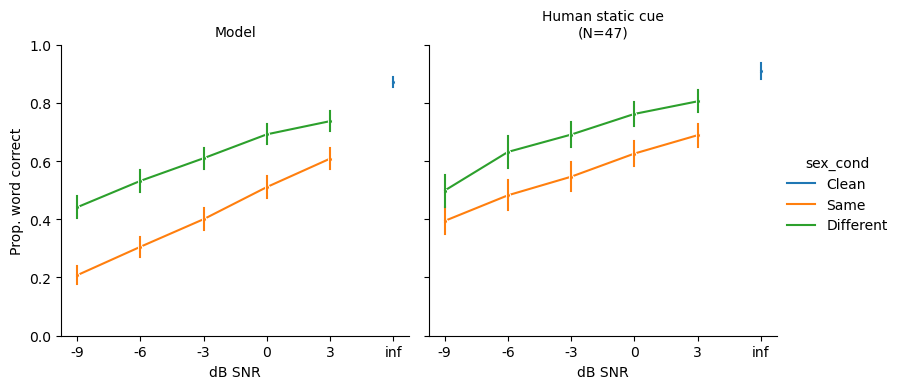

In [51]:
# cmap = sns.color_palette("gnuplot2", n_colors=3)

# palette = {lang:cmap[ix] for ix, lang in enumerate(['dutch', 'mandarin', 'english'])}
# palette['clean'] = 'k'

to_plot = combined_df.copy()
to_plot.loc[to_plot.snr == 'inf', 'snr'] = 6

g = sns.relplot(data=to_plot, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                col='group',
                # style='group', style_order = ['Human', 'word_task_half_co_loc_v07', 'word_task_half_co_loc_v08_gender_bal_4M_orig'],
                hue='sex_cond',
                kind='line', marker='.',
                # color='k',
                # palette=palette,
                height=4, aspect=1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = sorted(part_summary_df.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
# plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)

## Look at f0 analysis 

In [60]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_results['id_subject'] = all_model_results['group']
f0_analysis_df['group'] = f'Human (N={N})'

f0_analysis_df.reset_index(inplace=True, drop=True)
all_model_results.reset_index(inplace=True, drop=True)
combined_f0_df = pd.concat([f0_analysis_df, all_model_results],axis=0, ignore_index=True)

# combined_f0_df = combined_f0_df[combined_f0_df.background_condition == '1-talker']
combined_f0_df.loc[combined_f0_df.snr == "inf", 'snr'] = 6
combined_f0_df.snr = combined_f0_df.snr.astype('int')


Human (N=47)
Model


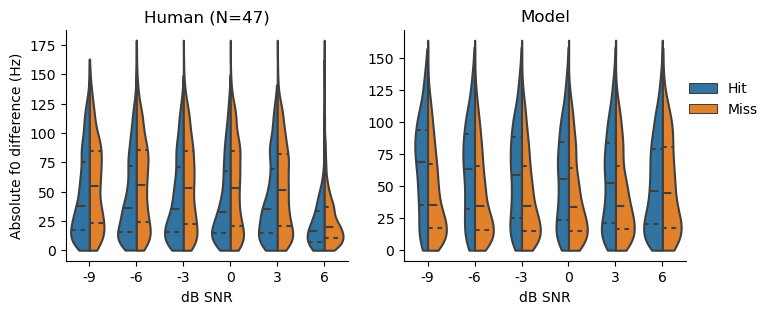

In [61]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
n_models = combined_f0_df.group.nunique()
fig, axes = plt.subplots(1,combined_f0_df.group.nunique(),figsize=(4 * n_models,3))

# need to fix, for now, toss bad examples 
# combined_f0_df.loc[combined_f0_df.abs_f0_diff > 200, 'abs_f0_diff'] = np.nan
combined_f0_df['correct_str'] = combined_f0_df['accuracy'].replace({0: "Miss", 1:"Hit"})

fontsize=10
for ix, group_name in enumerate(combined_f0_df.group.unique()):
    print(group_name)
    ax = sns.violinplot(data=combined_f0_df[combined_f0_df.group == group_name], x="snr", y="abs_f0_diff", cut=0, 
                        hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[ix])

    ax.set_title(group_name)
    if ix < n_models - 1:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Absolute f0 difference (Hz)', fontsize=fontsize)
    elif ix > 0:
        ax.set_ylabel('')
    ax.set_xlabel('dB SNR', fontsize=fontsize)


# if ix == 2:
sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


[  1.    40.75  80.5  120.25 160.  ]


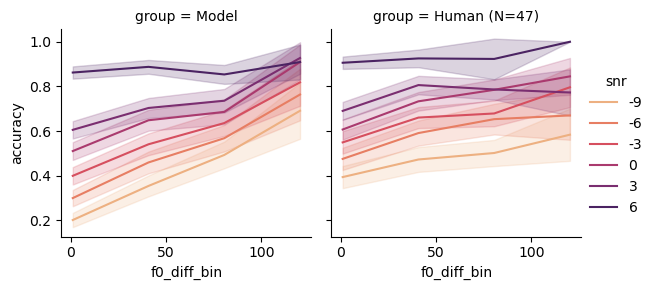

In [71]:
## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,7))].copy()
# histogram abs_f0_diff into 5 bins 
n_bins = 5

# min_f0_diff = to_plot[(to_plot.abs_f0_diff > 5) & (to_plot.group == 'participants')].abs_f0_diff.min()
# max_f0_diff = to_plot[(to_plot.group == 'participants')].abs_f0_diff.max()
bins = np.linspace(1, 160, n_bins)
# bins=[0,5,10,25,50,100]
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['abs_f0_diff'], bins=bins, labels=bins[:-1])
to_plot_model = to_plot[to_plot.group != f'Human (N={N})']
to_plot_human = to_plot[to_plot.group == f'Human (N={N})']

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)
sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line', palette='flare', height=3, aspect=1)


[0.25 0.6  0.95 1.3  1.65 2.  ]


/tmp/ipykernel_2432885/4113866154.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_model['group'] = 'Model'


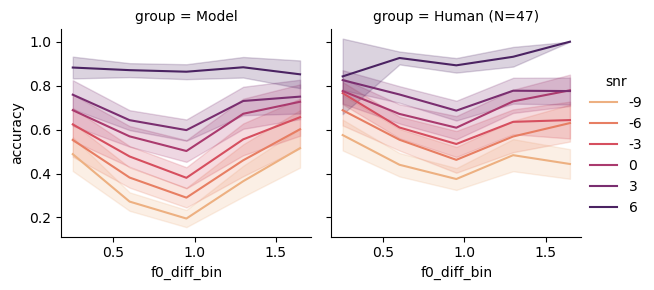

In [63]:
## Same but with percent f0 difference

## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,7))].copy()
# histogram percent_f0_diff into 5 bins 
n_bins = 6

# min_f0_diff = to_plot[(to_plot.percent_f0_diff > 5) & (to_plot.group == 'participants')].percent_f0_diff.min()
# max_f0_diff = to_plot[(to_plot.group == 'participants')].percent_f0_diff.max()
bins = np.linspace(0.25, 2, n_bins)

# bins=[0,5,10,25,50,100]
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['percent_f0_diff'], bins=bins, labels=bins[:-1], right=False)
# to_plot['f0_diff_bin'] = pd.qcut(to_plot['percent_f0_diff'], q=5, labels=['large low', 'small low', 'same', 'small up', 'large up'])

to_plot_model = to_plot[to_plot.group != f'Human (N={N})']
to_plot_human = to_plot[to_plot.group == f'Human (N={N})']

to_plot_model['group'] = 'Model'

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)
sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line', palette='flare', height=3, aspect=1)


In [64]:
def get_f0_ratio(target_f0, distractor_f0):
    return max(target_f0, distractor_f0) / min(target_f0, distractor_f0)

combined_f0_df['f0_ratio'] = combined_f0_df.apply(lambda x: get_f0_ratio(x.target_f0, x.distractor_f0), axis=1)

<AxesSubplot:>

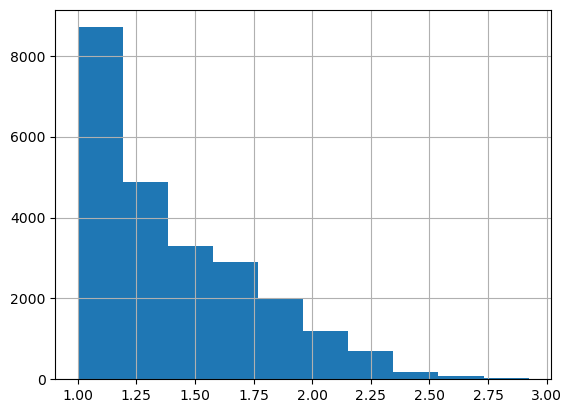

In [65]:
combined_f0_df['f0_ratio'].hist() 

[1.  1.4 1.8 2.2 2.6 3. ]


/tmp/ipykernel_2432885/4036085831.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_model['group'] = 'Model'
/tmp/ipykernel_2432885/4036085831.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot_model['group'] = 'Model'


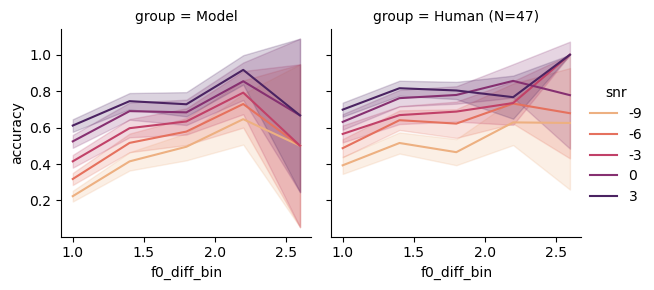

In [72]:
## Same but with percent f0 difference

## For f0 plots 
n_models = combined_f0_df.group.nunique()
to_plot = combined_f0_df[combined_f0_df.snr.isin(np.arange(-9,6))].copy()
# histogram percent_f0_diff into 5 bins 
n_bins = 6

# min_f0_diff = to_plot[(to_plot.percent_f0_diff > 5) & (to_plot.group == 'participants')].percent_f0_diff.min()
# max_f0_diff = to_plot[(to_plot.group == 'participants')].percent_f0_diff.max()
# bins = np.linspace(0.5,2, 9) 
bins = np.linspace(1, 3, n_bins)
# bins=[0,5,10,25,50,100]
print(bins)
to_plot['f0_diff_bin'] = pd.cut(to_plot['f0_ratio'], bins=bins, labels=bins[:-1], right=False)
# to_plot['f0_diff_bin'] = pd.qcut(to_plot['f0_ratio'],q=n_bins, labels=np.arange(n_bins))

to_plot_model = to_plot[to_plot.group != f'Human (N={N})']
to_plot_human = to_plot[to_plot.group == f'Human (N={N})']



to_plot_model['group'] = 'Model'
to_plot_model['group'] = 'Model'

to_plot_human = to_plot_human.groupby(['id_subject', 'snr', 'f0_diff_bin']).agg({'accuracy':np.nanmean, 'confusions':np.nanmean}).reset_index()
to_plot_human['group'] = f'Human (N={N})'

to_plot = pd.concat([to_plot_model, to_plot_human], axis=0, ignore_index=True)
sns.relplot(data=to_plot, x='f0_diff_bin', y='accuracy', col='group',
            errorbar=('se', 2),
            hue='snr', kind='line', palette='flare', height=3, aspect=1)


In [59]:
np.linspace(1.10,2, 10)

array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])